In [9]:
import torch
import torch.nn as nn
torch.manual_seed(42)


NUM_TRAJECTORIES = 3
T = 10
dt = 0.05
CHUNK_STEPS = 10

# Pendulum Params:
BETA = 0.4
OMEGA_0 = 9.81/2
K = 10

def u_func(t):
    if t < T//2:
        return torch.ones((NUM_TRAJECTORIES, 1))*0.5
    else:
        return torch.ones((NUM_TRAJECTORIES, 1))*(-0.7)

class PendulumWithSteering(nn.Module):
    def forward(self, t, state):
        theta = state[:, 0:1]
        omega = state[:, 1:2]

        u = u_func(t)

        domega_dt = -2*BETA*omega - OMEGA_0**2 * torch.sin(theta) + K * u
        dtheta_dt = omega

        return torch.cat([dtheta_dt, domega_dt], dim=1)


## Solver with steering

In [10]:
def zip_map(zipped, update_op):
    return [update_op(*elems) for elems in zipped]

def euler_update(h_list, dh_list, dt):
    return zip_map(zip(h_list, dh_list), lambda h, dh: h + dt * dh)

def euler_step(func, dt, state, action):
    return euler_update(state, func(state, action), dt)

def rk4_step(func, dt, state, action):
    k1 = func(state, action)
    k2 = func(euler_update(state, k1, dt / 2), action)
    k3 = func(euler_update(state, k2, dt / 2), action)
    k4 = func(euler_update(state, k3, dt), action)

    return zip_map(
        zip(state, k1, k2, k3, k4),
        lambda h, dk1, dk2, dk3, dk4: h + dt * (dk1 + 2 * dk2 + 2 * dk3 + dk4) / 6,)

In [11]:
from torchdiffeq import odeint
from matplotlib import pyplot as plt

trajectories_list = []

y_0s = torch.rand((NUM_TRAJECTORIES, 2))
y_0s[:, 0] *= 2 * torch.pi
y_0s[:, 1] -= 0.5
y_0s[:, 1] *= 20
ts = torch.linspace(0, T, int(T/dt))

true_system = PendulumWithSteering()
trajectories = odeint(true_system, y_0s, ts)

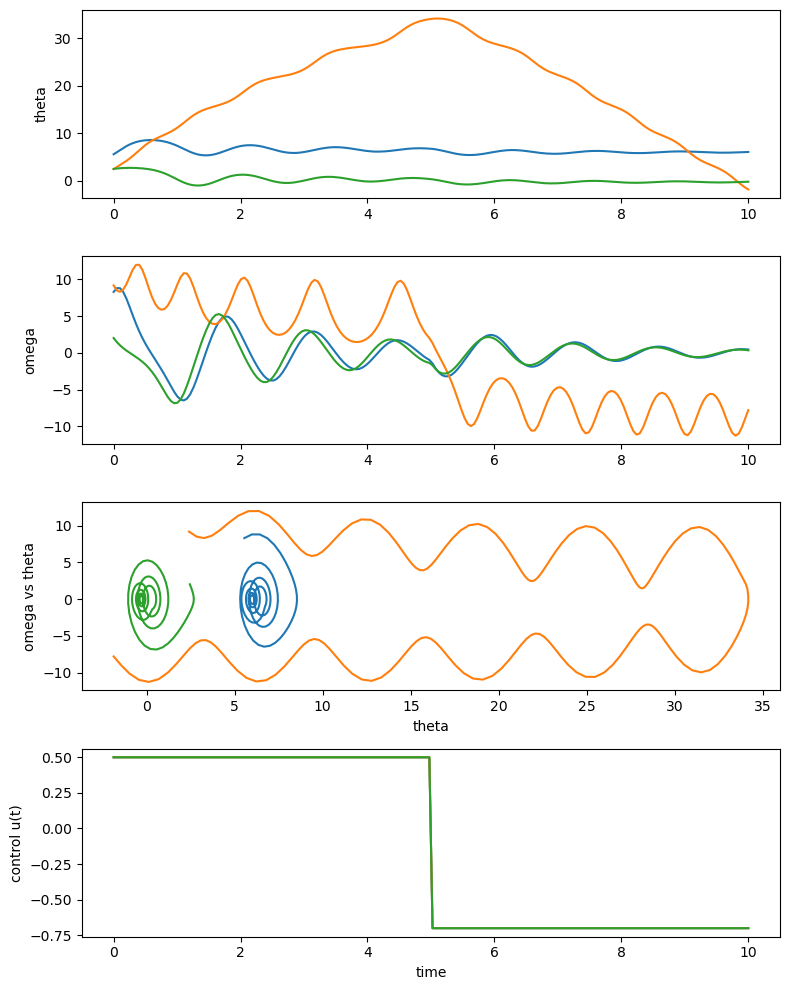

torch.Size([200, 3, 2])


In [12]:
fig, axs = plt.subplots(4, figsize=(8, 10))

for i in range(NUM_TRAJECTORIES):
    trajectory = trajectories[:, i, :] 
    thetas, omegas = trajectory[:, 0].tolist(), trajectory[:, 1].tolist()
    
    axs[0].plot(ts, thetas)
    axs[1].plot(ts, omegas)
    axs[2].plot(thetas, omegas)
    u_vals = [u_func(t.view(1))[i, 0].item() for t in ts]
    axs[3].plot(ts, u_vals)

axs[0].set_ylabel("theta")
axs[1].set_ylabel("omega")
axs[2].set_ylabel("omega vs theta")
axs[2].set_xlabel("theta")
axs[3].set_ylabel("control u(t)")
axs[3].set_xlabel("time")

plt.tight_layout()
plt.show()
print(trajectories.shape)

In [ ]:
from torchdiffeq import odeint_adjoint

class ODEFunc(nn.Module):
    """Neural network that parameterizes dy/dt = f(y, t)."""

    def __init__(self, u_callable):
        super().__init__()
        self.u_callable = u_callable
        self.net = nn.Sequential(
            nn.Linear(3, 50),
            nn.Tanh(),
            nn.Linear(50, 2),
        )

    def forward(self, t, y):
        u = self.u_callable(t)
        y_and_u = torch.cat([y, u], dim=-1)
        return self.net(y_and_u)

In [ ]:
class NeuralODE(nn.Module):
    """Wraps ODEFunc and solves it with torchdiffeq (Tsit5 solver)."""

    def __init__(self, odefun):
        super(NeuralODE, self).__init__()
        self.odefun = odefun
    
    def forward(self, y0, ts):
        
        return res

In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device = "cpu"
print(f"device: {device}")

model = NeuralODE(ODEFunc(u_func)).to(device)

# Data
y_0s = y_0s.to(device)
ts = ts.to(device)
trajectories = trajectories.to(device)

# hyperparameters
num_epochs_adam = 1000
num_epochs_bfgs = 100
print_every = 10
criterion = nn.MSELoss()

chunk_steps = int(CHUNK_LEN / dt)
num_chunks = int(T / CHUNK_LEN)

# phase 1: adam
print("--- starting adam phase ---")
optimizer1 = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(num_epochs_adam):
    optimizer1.zero_grad()
    epoch_loss = 0.0
    
    for c in range(num_chunks):
        start_idx = c * chunk_steps
        end_idx = start_idx + chunk_steps
        
        chunk_ts = ts[start_idx:end_idx] 
        chunk_y0 = trajectories[start_idx] 
        true_chunk = trajectories[start_idx:end_idx] 
        
        pred_chunk = model(chunk_y0, chunk_ts)
        
        loss = criterion(pred_chunk, true_chunk) / num_chunks
        loss.backward()
        
        epoch_loss += loss.item()
        
    optimizer1.step()

    if epoch % print_every == 0:
        print(f"Epoch {epoch:4d}, Loss: {epoch_loss:.6f}")

# phase 2: l-bfgs
print("\n--- starting l-bfgs phase ---")
optimizer2 = torch.optim.LBFGS(
    model.parameters(), 
    lr=0.01,
    max_iter=20,             
    max_eval=25,             
    tolerance_grad=1e-05,    
    tolerance_change=1e-09,  
    history_size=100,        
    line_search_fn='strong_wolfe'
)

for epoch in range(num_epochs_bfgs):
    def closure():
        optimizer2.zero_grad()
        total_closure_loss = 0.0
        
        for c in range(num_chunks):
            start_idx = c * chunk_steps
            end_idx = start_idx + chunk_steps
            
            chunk_ts = ts[start_idx:end_idx] 
            chunk_y0 = trajectories[start_idx] 
            true_chunk = trajectories[start_idx:end_idx] 
            
            pred_chunk = model(chunk_y0, chunk_ts)
            
            loss = criterion(pred_chunk, true_chunk) / num_chunks
            loss.backward()
            
            total_closure_loss += loss
            
        return total_closure_loss

    # optimizer.step() naturally returns the final loss evaluated during the closure
    final_loss = optimizer2.step(closure)

    if epoch % print_every == 0:
        # no recalculation needed, just print what the optimizer returned
        print(f"Epoch {epoch:4d}, Loss: {final_loss.item():.6f}")

device: cpu


NameError: name 'CHUNK_LEN' is not defined

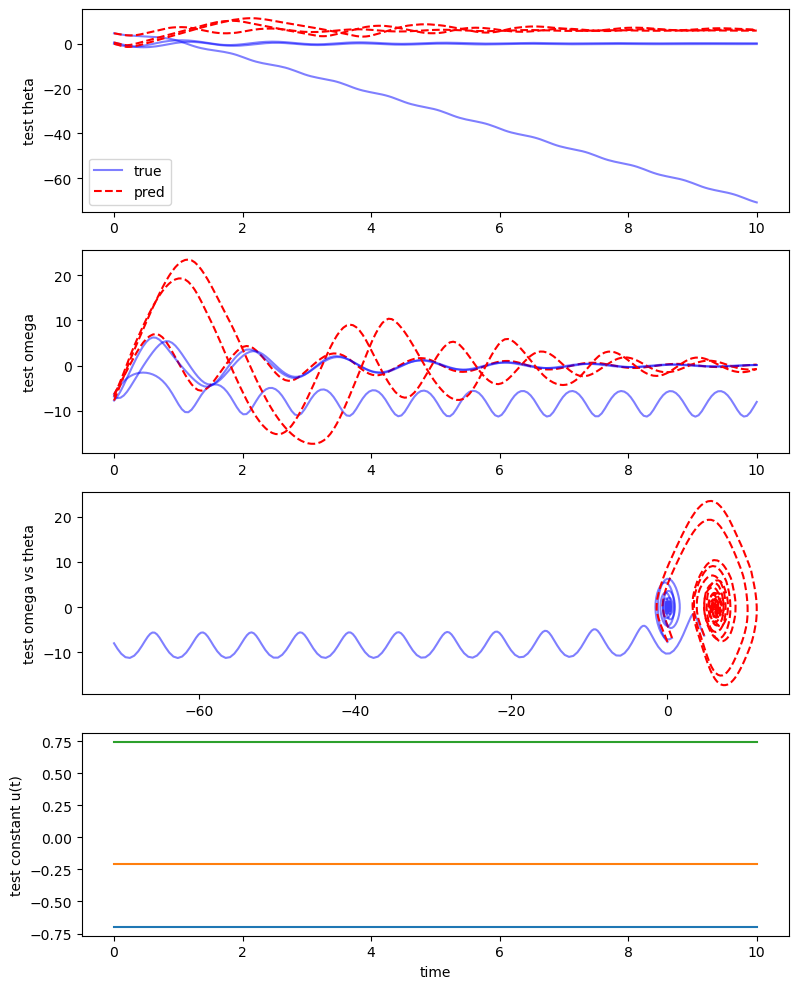

In [ ]:
# --- test evaluation ---
NUM_TEST_TRAJECTORIES = 3

# 1. create random constant u values bounded between -1 and 1
test_constants = (torch.rand((NUM_TEST_TRAJECTORIES, 1)) * 2) - 1

def test_u_func(t):
    return test_constants.to(t.device)

# 2. create a test version of the physics that uses the constant u
class TestPendulum(nn.Module):
    def forward(self, t, state):
        theta = state[:, 0:1]
        omega = state[:, 1:2]
        
        u = test_u_func(t)
        
        domega_dt = -2*BETA*omega - OMEGA_0**2 * torch.sin(theta) + K * u
        dtheta_dt = omega
        return torch.cat([dtheta_dt, domega_dt], dim=1)

# 3. generate completely random initial test states
test_y_0s = torch.rand((NUM_TEST_TRAJECTORIES, 2))
test_y_0s[:, 0] *= 2 * torch.pi
test_y_0s[:, 1] -= 0.5
test_y_0s[:, 1] *= 20
test_y_0s = test_y_0s.to(device)

test_system = TestPendulum().to(device)

with torch.no_grad():
    # get ground truth test trajectories
    test_true_traj = odeint(test_system, test_y_0s, ts)

    # swap the network's control function to point to the testing constants
    model.odefun.u_callable = test_u_func
    
    # generate predictions
    test_pred_traj = model(test_y_0s, ts)

# move to cpu for matplotlib
test_true_traj = test_true_traj.cpu().numpy()
test_pred_traj = test_pred_traj.cpu().numpy()
ts_cpu = ts.cpu().numpy()

# 4. plot it
fig, axs = plt.subplots(4, figsize=(8, 10))
for i in range(NUM_TEST_TRAJECTORIES):
    axs[0].plot(ts_cpu, test_true_traj[:, i, 0], 'b', alpha=0.5, label='true' if i==0 else "")
    axs[0].plot(ts_cpu, test_pred_traj[:, i, 0], 'r--', label='pred' if i==0 else "")
    
    axs[1].plot(ts_cpu, test_true_traj[:, i, 1], 'b', alpha=0.5)
    axs[1].plot(ts_cpu, test_pred_traj[:, i, 1], 'r--')
    
    axs[2].plot(test_true_traj[:, i, 0], test_true_traj[:, i, 1], 'b', alpha=0.5)
    axs[2].plot(test_pred_traj[:, i, 0], test_pred_traj[:, i, 1], 'r--')
    
    axs[3].plot(ts_cpu, [test_constants[i, 0].item()] * len(ts_cpu))

axs[0].legend()
axs[0].set_ylabel("test theta")
axs[1].set_ylabel("test omega")
axs[2].set_ylabel("test omega vs theta")
axs[3].set_ylabel("test constant u(t)")
axs[3].set_xlabel("time")
plt.tight_layout()
plt.show()